In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

**Import modules**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import KFold

import warnings
warnings.filterwarnings("ignore")

**Set up - Install Wandb**

In [3]:
!pip uninstall -y wandb
!pip install --no-cache-dir wandb==0.22.3

Found existing installation: wandb 0.25.1
Uninstalling wandb-0.25.1:
  Successfully uninstalled wandb-0.25.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 301.4 MB/s eta 0:00:00a 0:00:01


In [4]:
import wandb
print("wandb version:", wandb.__version__)

wandb version: 0.22.3


**WandB login**

In [5]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
WANDB_TOKEN = user_secrets.get_secret("WANDB_TOKEN")

wandb.login(key=WANDB_TOKEN)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

**Config**

In [6]:
TRAIN_PATH  = "/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv"
TEST_PATH   = "/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv"
SAMPLE_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv"

LABELS = ['A', 'B', 'C', 'D', 'E']
L2I = {l: i for i, l in enumerate(LABELS)}

WMIX = 0.6          # how much weight on word similarity vs char similarity
N_FOLDS = 5
SEED = 42

PROJECT = "DL-22f1000828-notebook-t22026"    # same wandb project as my other models

**Loading data**

In [7]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample = pd.read_csv(SAMPLE_PATH)

for df in [train, test]:
    for col in ['prompt'] + LABELS:
        df[col] = df[col].fillna("")

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Sample submission columns:", list(sample.columns))
train.head()

Train shape: (2000, 8)
Test shape : (500, 7)
Sample submission columns: ['ID', 'Prediction']


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


**EDA**

**Answer distribution**

answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64


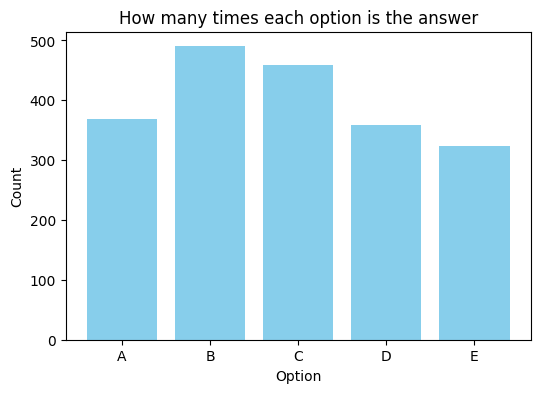


Random guessing MAP@3: 0.3667


In [8]:
counts = train['answer'].value_counts().reindex(LABELS, fill_value=0)
print(counts)

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, color='skyblue')
plt.title("How many times each option is the answer")
plt.xlabel("Option")
plt.ylabel("Count")
plt.show()

print()
print("Random guessing MAP@3:", round((1 + 1/2 + 1/3) / 5, 4))

**Duplicate and near duplicate questions**

In [9]:
print("Exact duplicate prompts inside train:", train['prompt'].duplicated().sum())

# how many test prompts appear word for word in train?
train_prompts = set(train['prompt'])
exact_matches = sum(1 for p in test['prompt'] if p in train_prompts)
print("Test prompts that also appear exactly in train:", exact_matches,
      "out of", len(test))

Exact duplicate prompts inside train: 242
Test prompts that also appear exactly in train: 268 out of 500


**How similar the closest training question**

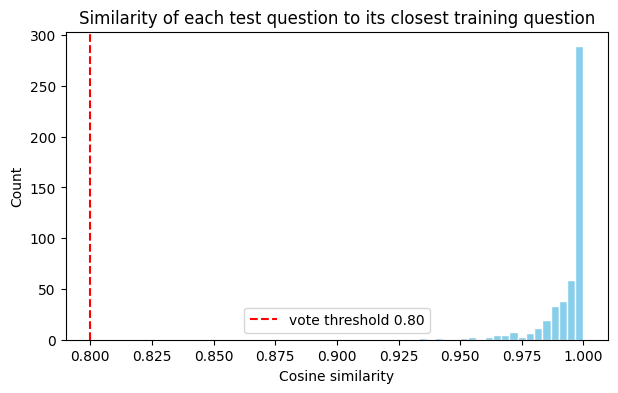

Test questions with a very close match (sim >= 0.80): 500 ( 100.0 % )
These are the ones the retrieval model can actually answer by voting.
The rest fall back to the heuristic.


In [10]:
def full_text(row):
    return str(row['prompt']) + " " + " ".join(str(row[c]) for c in LABELS)

train_texts = [full_text(r) for _, r in train.iterrows()]
test_texts = [full_text(r) for _, r in test.iterrows()]

quick_vec = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
quick_vec.fit(train_texts + test_texts)

Xq_tr = quick_vec.transform(train_texts)
Xq_te = quick_vec.transform(test_texts)

sim_quick = cosine_similarity(Xq_te, Xq_tr)
best_sim = sim_quick.max(axis=1)

plt.figure(figsize=(7, 4))
n_bins = 50 if best_sim.max() > best_sim.min() else 1
plt.hist(best_sim, bins=n_bins, color='skyblue', edgecolor='white')
plt.axvline(0.80, color='red', linestyle='--', label='vote threshold 0.80')
plt.title("Similarity of each test question to its closest training question")
plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.legend()
plt.show()

above = (best_sim >= 0.80).sum()
print("Test questions with a very close match (sim >= 0.80):", above,
      "(", round(above / len(test) * 100, 1), "% )")
print("These are the ones the retrieval model can actually answer by voting.")
print("The rest fall back to the heuristic.")

del sim_quick, Xq_tr, Xq_te

In [11]:
print("Building word and character TF-IDF")

word_vec = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, max_features=200000)
char_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                           sublinear_tf=True, max_features=120000)

word_vec.fit(train_texts + test_texts)
char_vec.fit(train_texts + test_texts)

Xw_tr = word_vec.transform(train_texts).astype(np.float32)
Xc_tr = char_vec.transform(train_texts).astype(np.float32)
Xw_te = word_vec.transform(test_texts).astype(np.float32)
Xc_te = char_vec.transform(test_texts).astype(np.float32)

print("Word features:", Xw_tr.shape[1])
print("Char features:", Xc_tr.shape[1])

train_label_idx = np.array([L2I[a] for a in train['answer']])

Building word and character TF-IDF
Word features: 13798
Char features: 23905


In [12]:
def heuristic_scores(row):
    prompt = str(row['prompt'])
    options = [str(row[c]) for c in LABELS]

    # score 1: how long is the option in characters
    lens = np.array([len(o) for o in options], dtype=float)
    len_s = lens / (lens.sum() + 1e-9)

    # score 2: how many words
    wcnt = np.array([len(o.split()) for o in options], dtype=float)
    wc_s = wcnt / (wcnt.sum() + 1e-9)

    # score 3: tf-idf similarity between the prompt and each option
    try:
        v = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True).fit_transform([prompt] + options)
        ts = cosine_similarity(v[0:1], v[1:])[0]
        tf_s = ts / (ts.sum() + 1e-9)
    except Exception:
        tf_s = np.full(5, 0.2)

    # if the option lengths differ a lot, trust length more
    if np.std(lens) >= 20:
        s = 0.85 * len_s + 0.03 * tf_s + 0.12 * wc_s
    else:
        s = 0.60 * len_s + 0.30 * tf_s + 0.10 * wc_s

    total = s.sum()
    if total > 0:
        return s / total
    return np.full(5, 0.2)

print("Computing heuristic scores")
train_heur = [heuristic_scores(r) for _, r in train.iterrows()]
test_heur = [heuristic_scores(r) for _, r in test.iterrows()]
print("Done")

Computing heuristic scores
Done


**The prediction function**

In [13]:
def combined_sim(qw, qc, rw, rc):
    # blend word similarity and char similarity
    return WMIX * cosine_similarity(qw, rw) + (1 - WMIX) * cosine_similarity(qc, rc)


def predict_baseline(sim_word, ref_labels, row):
    # simple version: vote using word similarity only
    order = np.argsort(sim_word)[::-1][:30]

    votes = np.zeros(5)
    total_weight = 0.0
    for j in order:
        s = sim_word[j]
        if s < 0.80:
            break
        votes[ref_labels[j]] += s ** 3
        total_weight += s ** 3

    h = heuristic_scores(row)
    if total_weight <= 0:
        return [int(x) for x in np.argsort(h)[::-1][:3]]

    r1 = int(np.argmax(votes))
    hh = h.copy()
    hh[r1] = -1
    r2 = int(np.argmax(hh))
    hh[r2] = -1
    r3 = int(np.argmax(hh))
    return [r1, r2, r3]


def predict_v3(sim_comb, sim_word, ref_labels, heur, p, top_k, base_thr, recall_thr, beta):
    # votes from word similarity (strict threshold, used for rank 1)
    ow = np.argsort(sim_word)[::-1][:30]
    bvotes = np.zeros(5)
    for j in ow:
        s = sim_word[j]
        if s < base_thr:
            break
        bvotes[ref_labels[j]] += s ** 3

    # votes from word+char similarity (looser threshold, recovers extra matches)
    oc = np.argsort(sim_comb)[::-1][:top_k]
    cvotes = np.zeros(5)
    for j in oc:
        s = sim_comb[j]
        if s < recall_thr:
            break
        cvotes[ref_labels[j]] += s ** p

    if bvotes.sum() > 0:
        rank1 = int(np.argmax(bvotes))
        secsrc = cvotes if cvotes.sum() > 0 else bvotes
    elif cvotes.sum() > 0:
        rank1 = int(np.argmax(cvotes))
        secsrc = cvotes
    else:
        # nothing similar enough, use the heuristic only
        return [int(x) for x in np.argsort(heur)[::-1][:3]]

    # ranks 2 and 3 come from a blend of votes and heuristic
    v = secsrc / secsrc.sum()
    sec = beta * v + (1 - beta) * heur
    sec[rank1] = -1e9
    rank2 = int(np.argmax(sec))
    sec[rank2] = -1e9
    rank3 = int(np.argmax(sec))
    return [rank1, rank2, rank3]


def map3(true_idx, pred_lists):
    total = 0.0
    for t, preds in zip(true_idx, pred_lists):
        for i, pi in enumerate(preds[:3]):
            if pi == t:
                total += 1.0 / (i + 1)
                break
    return total / len(true_idx)

**Cross validation and tuning**

In [14]:
print("Cross validating")
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# compute the similarity matrices once, then reuse them for every config
fold_cache = []
for tr_idx, va_idx in kf.split(range(len(train))):
    sim_c = combined_sim(Xw_tr[va_idx], Xc_tr[va_idx], Xw_tr[tr_idx], Xc_tr[tr_idx])
    sim_w = cosine_similarity(Xw_tr[va_idx], Xw_tr[tr_idx])
    fold_cache.append((
        sim_c,
        sim_w,
        train_label_idx[tr_idx],
        [train_heur[i] for i in va_idx],
        [train_label_idx[i] for i in va_idx],
        [train.iloc[i] for i in va_idx],
    ))
print("Similarity matrices ready")

Cross validating
Similarity matrices ready


In [15]:
# baseline score
wandb.init(project=PROJECT, name="tfidf-baseline", reinit=True,
           config={"method": "tfidf word-sim vote", "threshold": 0.80, "power": 3,
                   "n_folds": N_FOLDS},
           settings=wandb.Settings(save_code=False))

b_scores = []
for i, (sc, sw, lab, heur, true, rows) in enumerate(fold_cache):
    preds = [predict_baseline(sw[r], lab, rows[r]) for r in range(sw.shape[0])]
    fold_score = map3(true, preds)
    b_scores.append(fold_score)
    wandb.log({"fold": i + 1, "fold_map3": fold_score})   # one point per fold

baseline_cv = float(np.mean(b_scores))
print("Baseline CV MAP@3:", round(baseline_cv, 4))
print("Per fold:", [round(s, 4) for s in b_scores])

# summary uses the same key as my neural notebooks so the runs compare in the dashboard
wandb.summary["best_val_map3"] = baseline_cv
wandb.summary["cv_std"] = float(np.std(b_scores))
wandb.finish()

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Baseline CV MAP@3: 1.0
Per fold: [1.0, 1.0, 1.0, 1.0, 1.0]


fold,▁▃▅▆█
fold_map3,▁▁▁▁▁
best_val_map3,1
cv_std,0
fold,5
fold_map3,1


In [16]:
# grid search for the improved version
grid = []
for p in (3, 4):
    for k in (30, 50):
        for rt in (0.30, 0.40, 0.50):
            for be in (0.5, 0.7, 0.9):
                grid.append((p, k, 0.80, rt, be))

print("Trying", len(grid), "configs")

wandb.init(project=PROJECT, name="tfidf-tuned", reinit=True,
           config={"method": "tfidf word+char vote", "n_folds": N_FOLDS,
                   "grid_size": len(grid)},
           settings=wandb.Settings(save_code=False))

results = []
best_score = -1
best_cfg = None

for step, cfg in enumerate(grid):
    scores = []
    for sc, sw, lab, heur, true, rows in fold_cache:
        preds = [predict_v3(sc[r], sw[r], lab, heur[r], *cfg) for r in range(sc.shape[0])]
        scores.append(map3(true, preds))
    m = float(np.mean(scores))
    results.append({"p": cfg[0], "top_k": cfg[1], "recall_thr": cfg[3], "beta": cfg[4], "cv_map3": m})

    # log every config so I get a curve of the whole grid search in wandb
    wandb.log({"config_step": step, "cv_map3": m, "p": cfg[0], "top_k": cfg[1],
               "recall_thr": cfg[3], "beta": cfg[4]})

    if m > best_score:
        best_score = m
        best_cfg = cfg

new_cv = best_score
results_df = pd.DataFrame(results).sort_values("cv_map3", ascending=False)

# send the whole grid as a wandb table so I can sort it in the dashboard
wandb.log({"grid_results": wandb.Table(dataframe=results_df)})

wandb.summary["best_val_map3"] = new_cv
wandb.summary["baseline_map3"] = baseline_cv
wandb.summary["improvement"] = new_cv - baseline_cv
wandb.summary["best_p"] = best_cfg[0]
wandb.summary["best_top_k"] = best_cfg[1]
wandb.summary["best_recall_thr"] = best_cfg[3]
wandb.summary["best_beta"] = best_cfg[4]
wandb.finish()

print()
print("Baseline CV MAP@3:", round(baseline_cv, 4))
print("Tuned    CV MAP@3:", round(new_cv, 4))
print("Improvement      :", round(new_cv - baseline_cv, 4))
print("Best config (p, top_k, base_thr, recall_thr, beta):", best_cfg)
print()
print("Top 10 configs:")
print(results_df.head(10).to_string(index=False))

Trying 36 configs


beta,▁▅█▁▅█▁▅█▁▅█▁▅█▁▅█▁▅█▁▅█▁▅█▁▅█▁▅█▁▅█
config_step,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
cv_map3,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
p,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁██████████████████
recall_thr,▁▁▁▅▅▅███▁▁▁▅▅▅███▁▁▁▅▅▅███▁▁▁▅▅▅███
top_k,▁▁▁▁▁▁▁▁▁█████████▁▁▁▁▁▁▁▁▁█████████
baseline_map3,1
best_beta,0.5
best_p,3
best_recall_thr,0.3
best_top_k,30



Baseline CV MAP@3: 1.0
Tuned    CV MAP@3: 1.0
Improvement      : 0.0
Best config (p, top_k, base_thr, recall_thr, beta): (3, 30, 0.8, 0.3, 0.5)

Top 10 configs:
 p  top_k  recall_thr  beta  cv_map3
 3     30         0.3   0.5      1.0
 3     30         0.3   0.7      1.0
 3     30         0.3   0.9      1.0
 3     30         0.4   0.5      1.0
 3     30         0.4   0.7      1.0
 3     30         0.4   0.9      1.0
 3     30         0.5   0.5      1.0
 3     30         0.5   0.7      1.0
 3     30         0.5   0.9      1.0
 3     50         0.3   0.5      1.0


**Plot the tuning result**

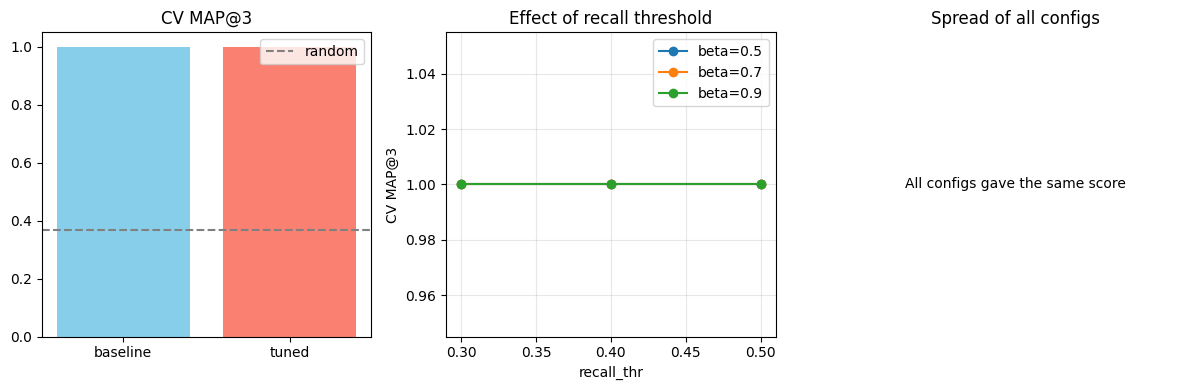

In [17]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.bar(['baseline', 'tuned'], [baseline_cv, new_cv], color=['skyblue', 'salmon'])
plt.axhline(0.3667, color='gray', linestyle='--', label='random')
plt.title("CV MAP@3")
plt.legend()

plt.subplot(1, 3, 2)
for beta in sorted(results_df['beta'].unique()):
    sub = results_df[results_df['beta'] == beta].sort_values('recall_thr')
    grouped = sub.groupby('recall_thr')['cv_map3'].mean()
    plt.plot(grouped.index, grouped.values, marker='o', label="beta=" + str(beta))
plt.title("Effect of recall threshold")
plt.xlabel("recall_thr")
plt.ylabel("CV MAP@3")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
# if every config gives the same score the histogram would fail, so I check first
if results_df['cv_map3'].nunique() > 1:
    plt.hist(results_df['cv_map3'], bins=20, color='skyblue', edgecolor='white')
    plt.title("Spread of all configs")
    plt.xlabel("CV MAP@3")
    plt.ylabel("Count")
else:
    plt.text(0.5, 0.5, "All configs gave the same score", ha='center', va='center')
    plt.title("Spread of all configs")
    plt.axis('off')

plt.tight_layout()
plt.show()

**Predictions and submission**

In [18]:
print("Generating test predictions")
sim_c_te = combined_sim(Xw_te, Xc_te, Xw_tr, Xc_tr)
sim_w_te = cosine_similarity(Xw_te, Xw_tr)

use_new = new_cv >= baseline_cv
print("Shipping:", "tuned model" if use_new else "baseline (safety fallback)")

pred_idx = []
for r in range(sim_c_te.shape[0]):
    if use_new:
        idx3 = predict_v3(sim_c_te[r], sim_w_te[r], train_label_idx, test_heur[r], *best_cfg)
    else:
        idx3 = predict_baseline(sim_w_te[r], train_label_idx, test.iloc[r])
    pred_idx.append(idx3)

pred_str = [" ".join(LABELS[i] for i in p) for p in pred_idx]
print("Done")

Generating test predictions
Shipping: tuned model
Done


In [19]:
id_col = sample.columns[0]
pred_col = sample.columns[1]

submission = pd.DataFrame({id_col: test['id'].values, pred_col: pred_str})

# keep the same row order as the sample submission
try:
    submission = sample[[id_col]].merge(submission, on=id_col, how='left')
except Exception:
    pass

submission.to_csv("submission.csv", index=False)

print("submission.csv created, rows:", len(submission))
print(submission.head(10).to_string(index=False))

submission.csv created, rows: 500
 ID Prediction
  1      A D C
  2      B A C
  3      B E C
  4      E C A
  5      C A D
  6      D A B
  7      E B D
  8      B D A
  9      C E D
 10      B E A


**How balanced are the predictions**

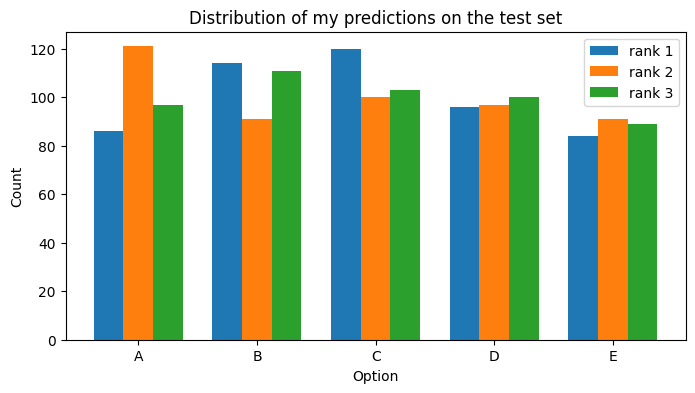

Rank 1: {'A': np.int64(86), 'B': np.int64(114), 'C': np.int64(120), 'D': np.int64(96), 'E': np.int64(84)}
Rank 2: {'A': np.int64(121), 'B': np.int64(91), 'C': np.int64(100), 'D': np.int64(97), 'E': np.int64(91)}
Rank 3: {'A': np.int64(97), 'B': np.int64(111), 'C': np.int64(103), 'D': np.int64(100), 'E': np.int64(89)}

Rank 1 should look roughly like the training answer distribution.


In [20]:
all_p = [p.split() for p in submission[pred_col]]

rank1 = pd.Series([p[0] for p in all_p]).value_counts().reindex(LABELS, fill_value=0)
rank2 = pd.Series([p[1] for p in all_p]).value_counts().reindex(LABELS, fill_value=0)
rank3 = pd.Series([p[2] for p in all_p]).value_counts().reindex(LABELS, fill_value=0)

x = np.arange(5)
plt.figure(figsize=(8, 4))
plt.bar(x - 0.25, rank1.values, width=0.25, label='rank 1')
plt.bar(x, rank2.values, width=0.25, label='rank 2')
plt.bar(x + 0.25, rank3.values, width=0.25, label='rank 3')
plt.xticks(x, LABELS)
plt.title("Distribution of my predictions on the test set")
plt.xlabel("Option")
plt.ylabel("Count")
plt.legend()
plt.show()

print("Rank 1:", dict(rank1))
print("Rank 2:", dict(rank2))
print("Rank 3:", dict(rank3))
print()
print("Rank 1 should look roughly like the training answer distribution.")